In [17]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression

In [19]:
df = pd.read_csv('Downloads/dataset_traffic_accident_prediction1.csv')
df.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0


In [21]:
df.isnull().sum()

Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density         42
Speed_Limit             42
Number_of_Vehicles      42
Driver_Alcohol          42
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age              42
Driver_Experience       42
Road_Light_Condition    42
Accident                42
dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               798 non-null    object 
 1   Road_Type             798 non-null    object 
 2   Time_of_Day           798 non-null    object 
 3   Traffic_Density       798 non-null    float64
 4   Speed_Limit           798 non-null    float64
 5   Number_of_Vehicles    798 non-null    float64
 6   Driver_Alcohol        798 non-null    float64
 7   Accident_Severity     798 non-null    object 
 8   Road_Condition        798 non-null    object 
 9   Vehicle_Type          798 non-null    object 
 10  Driver_Age            798 non-null    float64
 11  Driver_Experience     798 non-null    float64
 12  Road_Light_Condition  798 non-null    object 
 13  Accident              798 non-null    float64
dtypes: float64(7), object(7)
memory usage: 92.0+ KB


In [25]:
df.duplicated().sum()

14

In [29]:
df = df.dropna()

In [13]:
df = df.drop_duplicates(inplace=True)

In [31]:
df.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0
6,Foggy,Highway,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Truck,27.0,26.0,Daylight,1.0
7,Rainy,City Road,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Car,29.0,22.0,Artificial Light,1.0


In [33]:
df.shape

(405, 14)

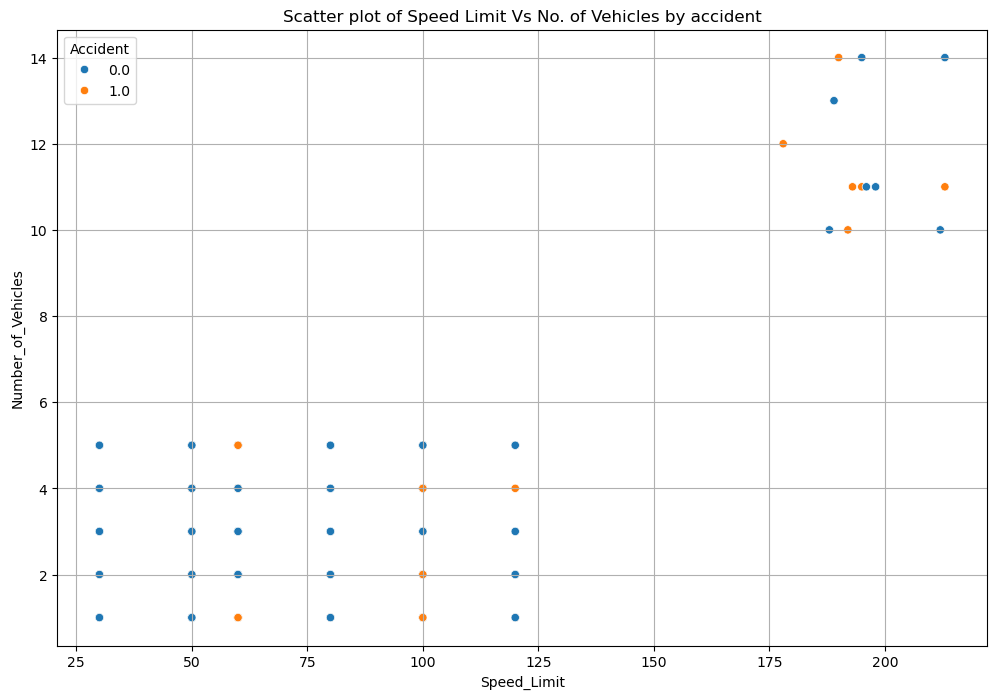

In [35]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x='Speed_Limit', y='Number_of_Vehicles', hue='Accident')
plt.title('Scatter plot of Speed Limit Vs No. of Vehicles by accident')
plt.xlabel('Speed_Limit')
plt.ylabel('Number_of_Vehicles')
plt.grid(True)
plt.show()

In [37]:
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col].fillna(-999,inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna('Unkown', inplace=True)



C:\Users\Shiva\AppData\Local\Temp\ipykernel_29820\3648431177.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(-999,inplace=True)
C:\Users\Shiva\AppData\Local\Temp\ipykernel_29820\3648431177.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doin

In [39]:
df.isnull().sum()

Weather                 0
Road_Type               0
Time_of_Day             0
Traffic_Density         0
Speed_Limit             0
Number_of_Vehicles      0
Driver_Alcohol          0
Accident_Severity       0
Road_Condition          0
Vehicle_Type            0
Driver_Age              0
Driver_Experience       0
Road_Light_Condition    0
Accident                0
dtype: int64

Correlation Matrix:


,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
Traffic_Density,1.000000,-0.064345,-0.045825,-0.011545,0.031097,0.030135,-0.031992
Speed_Limit,-0.064345,1.000000,0.512110,-0.009324,-0.005659,-0.010269,0.037021
Number_of_Vehicles,-0.045825,0.512110,1.000000,0.050515,0.029815,0.026365,0.122275
Driver_Alcohol,-0.011545,-0.009324,0.050515,1.000000,0.017405,0.022843,-0.016124
Driver_Age,0.031097,-0.005659,0.029815,0.017405,1.000000,0.982524,0.058734
Driver_Experience,0.030135,-0.010269,0.026365,0.022843,0.982524,1.000000,0.053896
Accident,-0.031992,0.037021,0.122275,-0.016124,0.058734,0.053896,1.000000


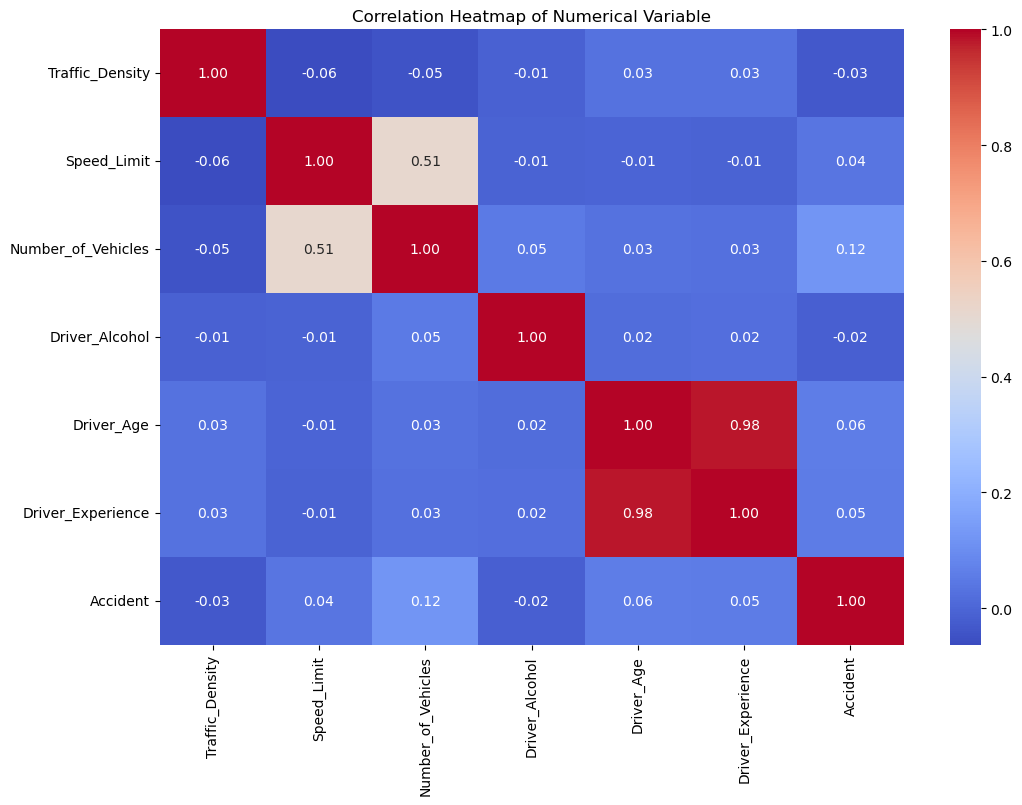

In [41]:
# Selecting only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64'])
# Calculating the correlation matrix
correlation_matrix = numerical_df.corr()
print('Correlation Matrix:')
display(correlation_matrix)
# Display Heatmap for better Visulaization.
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variable')
plt.show()

In [43]:
# Dropping columns with low correlation to 'Accident'
cols_to_drop = ['Traffic_Density', 'Speed_Limit', 'Driver_Alcohol', 'Driver_Age', 'Driver_Experience']
df = df.drop(columns=cols_to_drop)


In [45]:
df.head()

,Weather,Road_Type,Time_of_Day,Number_of_Vehicles,Accident_Severity,Road_Condition,Vehicle_Type,Road_Light_Condition,Accident
2,Rainy,Highway,Evening,4.0,Low,Icy,Car,Artificial Light,0.0
3,Clear,City Road,Afternoon,3.0,Low,Under Construction,Bus,Daylight,0.0
4,Rainy,Highway,Morning,11.0,Low,Dry,Car,Artificial Light,1.0
6,Foggy,Highway,Afternoon,4.0,Low,Dry,Truck,Daylight,1.0
7,Rainy,City Road,Afternoon,4.0,Low,Dry,Car,Artificial Light,1.0


In [47]:
df.shape

(405, 9)

In [49]:
df['Road_Type'].value_counts()

Road_Type
Highway          204
City Road        120
Rural Road        57
Mountain Road     24
Name: count, dtype: int64

In [51]:
df['Time_of_Day'].value_counts()


Time_of_Day
Afternoon    148
Evening      103
Morning       97
Night         57
Name: count, dtype: int64

In [53]:
df['Accident_Severity'].value_counts()


Accident_Severity
Low         243
Moderate    109
High         53
Name: count, dtype: int64

In [55]:
df['Accident_Severity'] = df['Accident_Severity'].replace({'Low':1, 'Moderate':2, 'High':3})

C:\Users\Shiva\AppData\Local\Temp\ipykernel_29820\2230696735.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Accident_Severity'] = df['Accident_Severity'].replace({'Low':1, 'Moderate':2, 'High':3})


In [57]:
df['Accident_Severity'].value_counts()

Accident_Severity
1    243
2    109
3     53
Name: count, dtype: int64

In [59]:
df['Road_Light_Condition'] = df['Road_Light_Condition'].replace({'Artificial Light': 1, 'Daylight':2, 'No Light':3,})


C:\Users\Shiva\AppData\Local\Temp\ipykernel_29820\3200015203.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Road_Light_Condition'] = df['Road_Light_Condition'].replace({'Artificial Light': 1, 'Daylight':2, 'No Light':3,})


In [61]:
df['Road_Light_Condition'].value_counts()

Road_Light_Condition
1    208
2    160
3     37
Name: count, dtype: int64

In [63]:
df['Vehicle_Type'] = df['Vehicle_Type'].replace({'Car':1,'Truck':4,'Motorcycle':2,'Bus':3})


C:\Users\Shiva\AppData\Local\Temp\ipykernel_29820\2699747711.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Vehicle_Type'] = df['Vehicle_Type'].replace({'Car':1,'Truck':4,'Motorcycle':2,'Bus':3})


In [65]:
df['Vehicle_Type'].value_counts()

Vehicle_Type
1    288
4     55
2     46
3     16
Name: count, dtype: int64

In [67]:
df['Road_Condition'] = df['Road_Condition'].replace({'Dry':1,'Icy':3,'Wet':2,'Under Construction':4})

C:\Users\Shiva\AppData\Local\Temp\ipykernel_29820\492177039.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Road_Condition'] = df['Road_Condition'].replace({'Dry':1,'Icy':3,'Wet':2,'Under Construction':4})


In [69]:
df['Road_Condition'].value_counts()

Road_Condition
1    211
3     81
2     71
4     42
Name: count, dtype: int64

In [71]:
df['Accident'].value_counts()

Accident
0.0    286
1.0    119
Name: count, dtype: int64

In [73]:
df['Accident'] = df['Accident'].replace({'0.0':1,'1.0':2})

In [75]:
df['Weather'].value_counts()

Weather
Clear     176
Rainy     112
Foggy      53
Snowy      45
Stormy     19
Name: count, dtype: int64

In [77]:
df['Weather'] = df['Weather'].replace({'Clear':1,'Rainy':2,'Foggy':3,'Snowy':4,'Stormy':5})

C:\Users\Shiva\AppData\Local\Temp\ipykernel_29820\1551001980.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Weather'] = df['Weather'].replace({'Clear':1,'Rainy':2,'Foggy':3,'Snowy':4,'Stormy':5})


In [79]:
df['Weather'].value_counts()

Weather
1    176
2    112
3     53
4     45
5     19
Name: count, dtype: int64

In [81]:
df['Road_Type'].value_counts()

Road_Type
Highway          204
City Road        120
Rural Road        57
Mountain Road     24
Name: count, dtype: int64

In [83]:
df['Road_Type'] = df['Road_Type'].replace({'Rural Road':1, 'City Road':2,'Highway':3,'Mountain Road':4})

C:\Users\Shiva\AppData\Local\Temp\ipykernel_29820\3536526239.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Road_Type'] = df['Road_Type'].replace({'Rural Road':1, 'City Road':2,'Highway':3,'Mountain Road':4})


In [85]:
df['Time_of_Day'].value_counts()

Time_of_Day
Afternoon    148
Evening      103
Morning       97
Night         57
Name: count, dtype: int64

In [87]:
df['Time_of_Day'] = df['Time_of_Day'].replace({'Morning':1,'Afternoon':2,'Evening':3,'Night':4})

C:\Users\Shiva\AppData\Local\Temp\ipykernel_29820\1631825694.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Time_of_Day'] = df['Time_of_Day'].replace({'Morning':1,'Afternoon':2,'Evening':3,'Night':4})


In [89]:
df['Time_of_Day'].value_counts()

Time_of_Day
2    148
3    103
1     97
4     57
Name: count, dtype: int64

In [91]:
df.head()

,Weather,Road_Type,Time_of_Day,Number_of_Vehicles,Accident_Severity,Road_Condition,Vehicle_Type,Road_Light_Condition,Accident
2,2,3,3,4.0,1,3,1,1,0.0
3,1,2,2,3.0,1,4,3,2,0.0
4,2,3,1,11.0,1,1,1,1,1.0
6,3,3,2,4.0,1,1,4,2,1.0
7,2,2,2,4.0,1,1,1,1,1.0


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 405 entries, 2 to 839
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               405 non-null    int64  
 1   Road_Type             405 non-null    int64  
 2   Time_of_Day           405 non-null    int64  
 3   Number_of_Vehicles    405 non-null    float64
 4   Accident_Severity     405 non-null    int64  
 5   Road_Condition        405 non-null    int64  
 6   Vehicle_Type          405 non-null    int64  
 7   Road_Light_Condition  405 non-null    int64  
 8   Accident              405 non-null    float64
dtypes: float64(2), int64(7)
memory usage: 31.6 KB


In [95]:
# Training and testing

In [97]:
X = df.drop(columns=['Accident'], axis=1)
y = df['Accident']

In [99]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42 )


In [101]:
scaler= StandardScaler()

In [103]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [105]:
Log = LogisticRegression()

In [107]:
Log.fit(X_train, y_train)

LogisticRegression()

In [109]:
y_pred = Log.predict(X_test)

In [111]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print(f"""The Accuracy : {accuracy * 100:.2f}%""")

The Accuracy : 67.90%


In [113]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.70      0.96      0.81        57
         1.0       0.00      0.00      0.00        24

    accuracy                           0.68        81
   macro avg       0.35      0.48      0.40        81
weighted avg       0.49      0.68      0.57        81

